# Neural Networks for Binary Classification

In this activity, we will use a simple artificial neural network to fit a model the provides the best decision boundary to the data provided. At this point of the lecture, you will learn that while traditional curve fitting might struggle with non-linear relationships or interactions between multiple variables, neural networks excel in these areas due to their layered architecture and non-linear activation functions. Essentially, a neural network can be thought of as performing a highly sophisticated form of curve fitting. It adjusts its internal parameters (weights and biases) during training to minimize the loss function, analogous to how coefficients are adjusted in polynomial curve fitting. This enables neural networks to fit intricate patterns in data, making them powerful tools for tasks that involve image recognition, natural language processing, and more, where traditional models might fail to capture the complexity of the data.

This notebook assists learning the advantages of combinining non-linear activations with a more complex model architecture i.e., a neural network.

## Neural network architecture

The following illustration is our model architecture. It is a simple neural network with two inputs (i.e., `Feature 0` and `Feature 1`), a single `hidden` layer with two `nodes` or `units`, and an output layer with a single `node`. In binary classification tasks, meaning, those that answer "Yes"/"No", "Positive"/"Negative", and "Class 0" vs "Class 1" questions, a single output node will do. The values here are then thresholded, meaning we set a value decision boundary and anything north or south of that value are mapped to the two classes of outputs. The labels in the illustration should guide you when changing the slider values for each parameter in the network.


<center><img src="https://github.com/mikedataCrunch/GMS5204/blob/main/media/nn_activity.jpeg?raw=true"/></center>
<center><b>Figure 1. Simple neural network architecture: 2 input features, 1 hidden layer with 2 nodes, and an output layer with a single node.</b></center>

## Data description
The sample data we're using here resembles a binary classification, where each sample belongs to either `Class: 0` or `Class: 1`. This is quite common in tasks that requires identifying examples that are `positive` to a particular condition, disease, diagnosis, or some other classification criteria.

The binary classification task takes in two input `features`. We can think of features as characteristics of an example. If consider humans as examples, then the two features can be height & weight, age & gender, gender & income, etc. If we consider this in a medical sense, then the two features can be test result A & B, lifestyle & age, or whatever pair of characteristics available to us.

In our activity, we will refer to these as `Feature 0` and `Feature 1`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interactive, FloatSlider, Layout, interact
import ipywidgets as widgets
from IPython.display import display

def ReLU(x):
    """ReLU: Rectified linear unit function."""
    return np.maximum(0, x)

def sigmoid(x):
    """Numerically stable sigmoid function."""
    x = np.asarray(x, dtype=float)
    result = np.empty_like(x)
    nonnegative = x >= 0
    result[nonnegative] = 1 / (1 + np.exp(-x[nonnegative]))
    exp_x = np.exp(x[~nonnegative])
    result[~nonnegative] = exp_x / (1 + exp_x)
    return result

# Define the neural network with one hidden layer
def simple_neural_network(inputs, w1, w2, b1, b2):
    # Inputs is expected to be Nx2, w1 is 2x2, b1 is size 2, w2 is size 2, b2 is a scalar
    hidden_layer_input = np.dot(inputs, w1) + b1
    hidden_layer_activation = ReLU(hidden_layer_input) 
    output = np.dot(hidden_layer_activation, w2) + b2
    return sigmoid(output)

def calculate_bce_loss(y_true, y_pred):
    """
    Calculate the binary cross-entropy loss.

    Parameters:
    -----------
    y_true (array-like): True binary labels (0 or 1).
    y_pred (array-like): Predicted probabilities, between 0 and 1.

    Returns:
    --------
    float: The average binary cross-entropy loss.
    """
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    if y_true.shape != y_pred.shape:
        raise ValueError("y_true and y_pred must have the same shape")

    # Ensure that y_pred does not contain values exactly equal to 0 or 1,
    # as log(0) is undefined and can cause computation errors.
    epsilon = 1e-10
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    # Calculate binary cross-entropy loss
    loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return loss

In [2]:

# Generate a simple dataset
np.random.seed(42)
# Class 0
feature_0_class_0 = np.random.normal(2, 1, 100)  # Feature 1 for class 0
feature_1_class_0 = np.random.normal(2, 1, 100)  # Feature 2 for class 0
# Class 1
feature_0_class_1 = np.random.normal(5, 1, 100)  # Feature 1 for class 1
feature_1_class_1 = np.random.normal(5, 1, 100)  # Feature 2 for class 1

features = np.vstack((np.column_stack((feature_0_class_0, feature_1_class_0)),
                      np.column_stack((feature_0_class_1, feature_1_class_1))))
y_true = np.array([0]*100 + [1]*100)

In [ ]:
offset = 10
# offset = 0
# Grid for decision boundary visualization
feature_0, feature_1 = np.meshgrid(
    np.linspace(
        min(np.concatenate([feature_0_class_0, feature_0_class_1])) - offset, 
        max(np.concatenate([feature_0_class_0, feature_0_class_1])) + offset, 
        30
    ),
    np.linspace(
        min(np.concatenate([feature_1_class_0, feature_1_class_1])) - offset, 
        max(np.concatenate([feature_1_class_0, feature_1_class_1])) + offset, 
        30
    ),
)
# initial slider vals
w1_00_init = 2
w1_01_init = 2
w1_10_init = 2
w1_11_init = 2
w2_0_init = 0.5
w2_1_init = -0.4

b1_0_init = -1
b1_1_init = -1
b2_init = -1


# slider range
min_, max_ = -10, 10

slider_style = {'description_width': 'initial', 'handle_color': 'lightblue'}  # Adjust handle color and description width
layout = Layout(width='600px')
# Plotting function
@interact(
    w1_00=FloatSlider(description="w_x0_h0", value=w1_00_init, min=min_, max=max_, step=0.01, style=slider_style, layout=layout,),
    w1_01=FloatSlider(description="w_x0_h1", value=w1_01_init, min=min_, max=max_, step=0.01, style=slider_style, layout=layout,),
    w1_10=FloatSlider(description="w_x1_h0", value=w1_10_init, min=min_, max=max_, step=0.01, style=slider_style, layout=layout,),
    w1_11=FloatSlider(description="w_x1_h1", value=w1_11_init, min=min_, max=max_, step=0.01, style=slider_style, layout=layout,),
    b1_0=FloatSlider(description="b_h0", value=b1_0_init, min=min_, max=max_, step=0.01, style=slider_style, layout=layout,),
    b1_1=FloatSlider(description="b_h1", value=b1_1_init, min=min_, max=max_, step=0.01, style=slider_style, layout=layout,),
    w2_0=FloatSlider(description="w_h0_out", value=w2_0_init, min=min_, max=max_, step=0.01, style=slider_style, layout=layout,),
    w2_1=FloatSlider(description="w_h1_out", value=w2_1_init, min=min_, max=max_, step=0.01, style=slider_style, layout=layout,),
    b2=FloatSlider(description="b_out", value=b2_init, min=min_, max=max_, step=0.01, style=slider_style, layout=layout,),
    continuous_update=False,
)
def plot_nn_decision_boundary(w1_00, w1_01, w1_10, w1_11, b1_0, b1_1, w2_0, w2_1, b2):
    w1 = np.array([[w1_00, w1_01], [w1_10, w1_11]])
    b1 = np.array([b1_0, b1_1])
    w2 = np.array([w2_0, w2_1])
    b2 = float(b2)
    
    zz = simple_neural_network(np.c_[feature_0.ravel(), feature_1.ravel()], w1, w2, b1, b2)
    zz = zz.reshape(feature_0.shape)

    plt.figure(figsize=(10, 8))
    plt.scatter(
        features[:,0][:y_true.size // 2], 
        features[:,1][:y_true.size // 2], 
        c='blue',
        label='Class: 0',
        alpha=0.8
    )
    plt.scatter(
        features[:,0][y_true.size // 2:], 
        features[:,1][y_true.size // 2:], 
        c='red',
        label='Class: 1',
        alpha=0.8
    )  
    
    contour = plt.contourf(
        feature_0, 
        feature_1, 
        zz, 
        levels=[0, 0.5, 1], 
        alpha=0.3, 
        cmap="coolwarm",
    )
    plt.colorbar(contour)
    # Decision boundary line for the zz = 0.5 threshold
    plt.contour(
        feature_0, 
        feature_1, 
        zz, 
        levels=[0.5],
        colors='k', 
        vmin=0, 
        vmax=1, 
        linestyles='dashed')

    # Calculate loss
    y_pred = simple_neural_network(np.c_[features[:,0].ravel(), features[:,1].ravel()], w1, w2, b1, b2)
    loss = calculate_bce_loss(y_true, y_pred)
    
    plt.annotate(f"Current BCE Loss: {loss:.4f}", xy=(5,2), fontsize=10)
    plt.title('Neural Network Decision Boundary')
    plt.xlabel('Feature 0')
    plt.ylabel('Feature 1')
    plt.legend()    
    plt.grid(True)
    plt.show()
    # 3.64, 1.78, 2.66, -4.96, -2.59, -1.26, 0.05, -8.08, -1.21

interactive(children=(FloatSlider(value=2.0, description='w_x0_h0', layout=Layout(width='600px'), max=10.0, mi…

## Train the Neural Network

The sliders above let us explore how each parameter changes the decision boundary. We can also let the same 2-input, 2-hidden-unit, 1-output network learn those parameters automatically. The following cell uses full-batch gradient descent to minimise binary cross-entropy loss.

In [4]:
# Train the illustrated 2-input, 2-hidden-unit, 1-output neural network.
rng = np.random.default_rng(42)
trained_w1 = rng.normal(0, 0.25, size=(2, 2))
trained_b1 = np.zeros(2)
trained_w2 = rng.normal(0, 0.25, size=2)
trained_b2 = 0.0

learning_rate = 0.05
epochs = 3000
loss_history = []
n_samples = features.shape[0]

for epoch in range(epochs):
    # Forward pass
    hidden_input = features @ trained_w1 + trained_b1
    hidden_output = ReLU(hidden_input)
    logits = hidden_output @ trained_w2 + trained_b2
    y_pred = sigmoid(logits)
    loss_history.append(calculate_bce_loss(y_true, y_pred))

    # Backward pass
    d_logits = (y_pred - y_true) / n_samples
    d_w2 = hidden_output.T @ d_logits
    d_b2 = d_logits.sum()
    d_hidden = d_logits[:, None] * trained_w2
    d_hidden_input = d_hidden * (hidden_input > 0)
    d_w1 = features.T @ d_hidden_input
    d_b1 = d_hidden_input.sum(axis=0)

    # Update parameters
    trained_w1 -= learning_rate * d_w1
    trained_b1 -= learning_rate * d_b1
    trained_w2 -= learning_rate * d_w2
    trained_b2 -= learning_rate * d_b2

trained_predictions = simple_neural_network(
    features, trained_w1, trained_w2, trained_b1, trained_b2
)
trained_loss = calculate_bce_loss(y_true, trained_predictions)
trained_accuracy = np.mean((trained_predictions >= 0.5) == y_true)
print(f"Final BCE loss: {trained_loss:.4f}")
print(f"Training accuracy: {trained_accuracy:.1%}")


Final BCE loss: 0.0342
Training accuracy: 99.5%


## Trained Decision Boundary

The dashed line shows where the trained network assigns equal probability to each class.

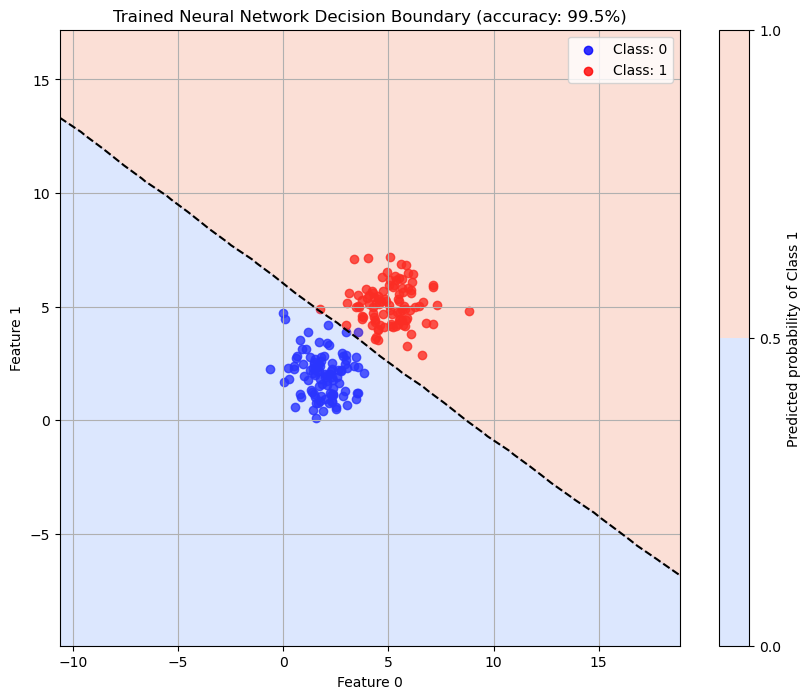

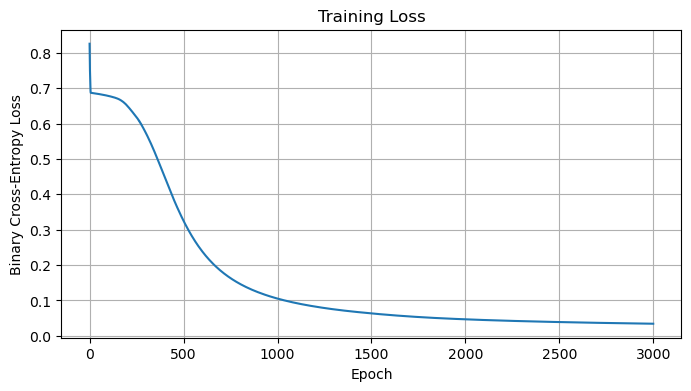

In [5]:
grid_inputs = np.c_[feature_0.ravel(), feature_1.ravel()]
trained_zz = simple_neural_network(
    grid_inputs, trained_w1, trained_w2, trained_b1, trained_b2
).reshape(feature_0.shape)

plt.figure(figsize=(10, 8))
plt.scatter(features[:100, 0], features[:100, 1], c='blue', label='Class: 0', alpha=0.8)
plt.scatter(features[100:, 0], features[100:, 1], c='red', label='Class: 1', alpha=0.8)
contour = plt.contourf(
    feature_0, feature_1, trained_zz, levels=[0, 0.5, 1], alpha=0.3, cmap='coolwarm'
)
plt.colorbar(contour, label='Predicted probability of Class 1')
plt.contour(feature_0, feature_1, trained_zz, levels=[0.5], colors='k', linestyles='dashed')
plt.title(f'Trained Neural Network Decision Boundary (accuracy: {trained_accuracy:.1%})')
plt.xlabel('Feature 0')
plt.ylabel('Feature 1')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.grid(True)
plt.show()


## A More Challenging Classification Dataset

The concentric-rings dataset below has an inner class and an outer class. A straight decision boundary cannot separate these classes, so it gives us a clear visual example of why hidden layers and non-linear activations are useful.

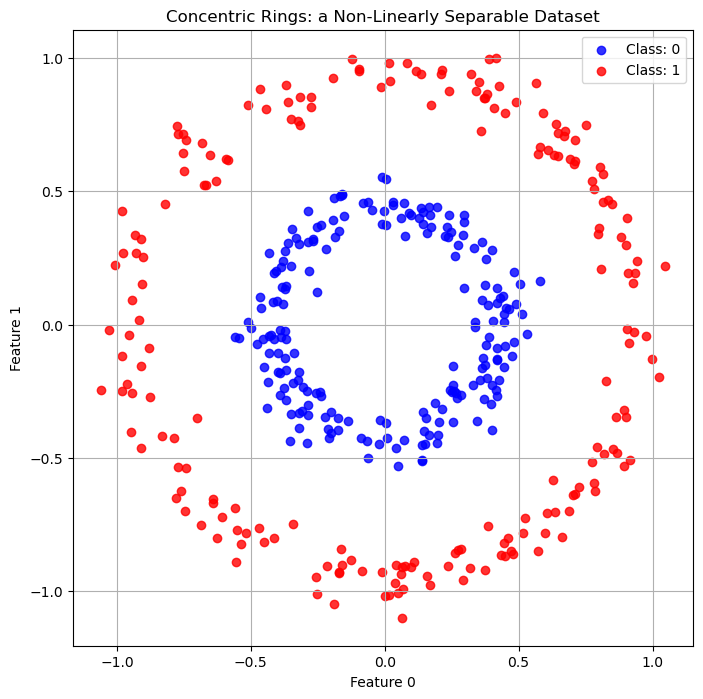

In [6]:
# Generate two noisy concentric rings.
data_rng = np.random.default_rng(7)
n_per_class = 200

inner_angles = data_rng.uniform(0, 2 * np.pi, n_per_class)
outer_angles = data_rng.uniform(0, 2 * np.pi, n_per_class)
inner_radius = 0.45 + data_rng.normal(0, 0.06, n_per_class)
outer_radius = 0.95 + data_rng.normal(0, 0.06, n_per_class)

inner_ring = np.column_stack((inner_radius * np.cos(inner_angles), inner_radius * np.sin(inner_angles)))
outer_ring = np.column_stack((outer_radius * np.cos(outer_angles), outer_radius * np.sin(outer_angles)))
hard_features = np.vstack((inner_ring, outer_ring))
hard_y_true = np.array([0] * n_per_class + [1] * n_per_class)

# Shuffle samples while retaining each feature/label pairing.
order = data_rng.permutation(hard_y_true.size)
hard_features = hard_features[order]
hard_y_true = hard_y_true[order]

plt.figure(figsize=(8, 8))
plt.scatter(hard_features[hard_y_true == 0, 0], hard_features[hard_y_true == 0, 1], c='blue', label='Class: 0', alpha=0.8)
plt.scatter(hard_features[hard_y_true == 1, 0], hard_features[hard_y_true == 1, 1], c='red', label='Class: 1', alpha=0.8)
plt.title('Concentric Rings: a Non-Linearly Separable Dataset')
plt.xlabel('Feature 0')
plt.ylabel('Feature 1')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()


## Solve the Concentric-Rings Problem

We retain the same input and output layers, but use 16 hidden ReLU units. The additional units give the model enough flexible pieces to approximate the circular decision boundary.

<center><img src="https://github.com/mikedataCrunch/GMS5204/blob/main/media/nn_activity_2.png?raw=true"/></center>
<center><b>Neural network architecture for concentric-rings binary classification: two input features feed into a hidden layer of 16 ReLU units, followed by a sigmoid output that estimates the probability of Class 1.</b></center>

In [7]:
# Train a 2-input, 16-hidden-unit, 1-output neural network.
training_rng = np.random.default_rng(19)
hidden_units = 16
hard_w1 = training_rng.normal(0, np.sqrt(2 / 2), size=(2, hidden_units))
hard_b1 = np.zeros(hidden_units)
hard_w2 = training_rng.normal(0, np.sqrt(2 / hidden_units), size=hidden_units)
hard_b2 = 0.0

hard_learning_rate = 0.1
hard_epochs = 5000
hard_loss_history = []
hard_n_samples = hard_features.shape[0]

for epoch in range(hard_epochs):
    # Forward pass
    hard_hidden_input = hard_features @ hard_w1 + hard_b1
    hard_hidden_output = ReLU(hard_hidden_input)
    hard_logits = hard_hidden_output @ hard_w2 + hard_b2
    hard_y_pred = sigmoid(hard_logits)
    hard_loss_history.append(calculate_bce_loss(hard_y_true, hard_y_pred))

    # Backward pass and parameter update
    hard_d_logits = (hard_y_pred - hard_y_true) / hard_n_samples
    hard_d_w2 = hard_hidden_output.T @ hard_d_logits
    hard_d_b2 = hard_d_logits.sum()
    hard_d_hidden = hard_d_logits[:, None] * hard_w2
    hard_d_hidden_input = hard_d_hidden * (hard_hidden_input > 0)
    hard_d_w1 = hard_features.T @ hard_d_hidden_input
    hard_d_b1 = hard_d_hidden_input.sum(axis=0)

    hard_w1 -= hard_learning_rate * hard_d_w1
    hard_b1 -= hard_learning_rate * hard_d_b1
    hard_w2 -= hard_learning_rate * hard_d_w2
    hard_b2 -= hard_learning_rate * hard_d_b2

hard_trained_predictions = simple_neural_network(
    hard_features, hard_w1, hard_w2, hard_b1, hard_b2
)
hard_trained_loss = calculate_bce_loss(hard_y_true, hard_trained_predictions)
hard_trained_accuracy = np.mean((hard_trained_predictions >= 0.5) == hard_y_true)
print(f"Final BCE loss: {hard_trained_loss:.4f}")
print(f"Training accuracy: {hard_trained_accuracy:.1%}")


Final BCE loss: 0.0066
Training accuracy: 100.0%


## Learned Boundary for the Concentric Rings

The trained network assigns the outer region to Class 1 and the central region to Class 0, producing a non-linear boundary that a single linear classifier cannot create.

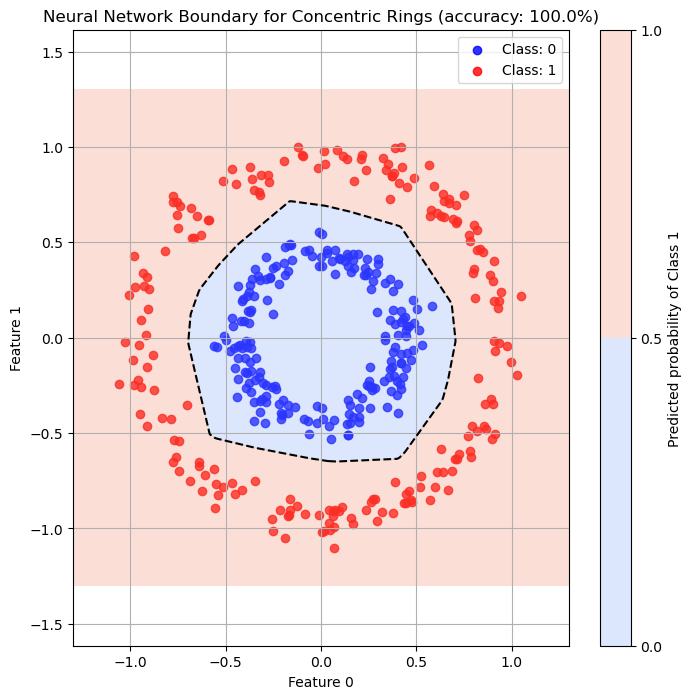

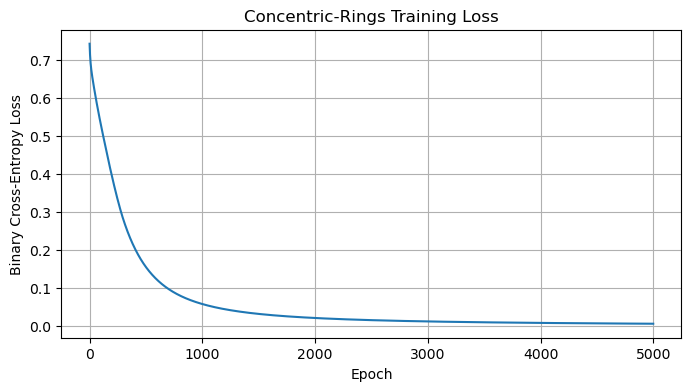

In [8]:
grid_limit = np.abs(hard_features).max() + 0.2
hard_grid_0, hard_grid_1 = np.meshgrid(
    np.linspace(-grid_limit, grid_limit, 200),
    np.linspace(-grid_limit, grid_limit, 200),
)
hard_grid_inputs = np.c_[hard_grid_0.ravel(), hard_grid_1.ravel()]
hard_zz = simple_neural_network(
    hard_grid_inputs, hard_w1, hard_w2, hard_b1, hard_b2
).reshape(hard_grid_0.shape)

plt.figure(figsize=(8, 8))
plt.scatter(hard_features[hard_y_true == 0, 0], hard_features[hard_y_true == 0, 1], c='blue', label='Class: 0', alpha=0.8)
plt.scatter(hard_features[hard_y_true == 1, 0], hard_features[hard_y_true == 1, 1], c='red', label='Class: 1', alpha=0.8)
contour = plt.contourf(hard_grid_0, hard_grid_1, hard_zz, levels=[0, 0.5, 1], alpha=0.3, cmap='coolwarm')
plt.colorbar(contour, label='Predicted probability of Class 1')
plt.contour(hard_grid_0, hard_grid_1, hard_zz, levels=[0.5], colors='k', linestyles='dashed')
plt.title(f'Neural Network Boundary for Concentric Rings (accuracy: {hard_trained_accuracy:.1%})')
plt.xlabel('Feature 0')
plt.ylabel('Feature 1')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(hard_loss_history)
plt.title('Concentric-Rings Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.grid(True)
plt.show()


## End.